In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from tobii_pytracker.analyze.data_loader import DataLoader
from tobii_pytracker.configs.custom_config import CustomConfig

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from tobii_pytracker.analyze.models import (
    HeatmapAnalyzer,
    FocusMapAnalyzer,
    FixationAnalyzer,
    SaccadeAnalyzer,
    EntropyAnalyzer,
    ClusterAnalyzer,
    ScanpathsAnalyzer,
)


config = CustomConfig('./configs/config.yaml')
loader = DataLoader(config, root='./')

▶ Global heatmap statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,-31.962761,32.264814,4887


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260915_115512,-31.962761,32.264814,4887


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260915_115512,0,-14.596334,98.456481,1545
1,20260915_115512,1,-32.643512,8.548326,1811
2,20260915_115512,2,-48.682740,-6.478206,1531


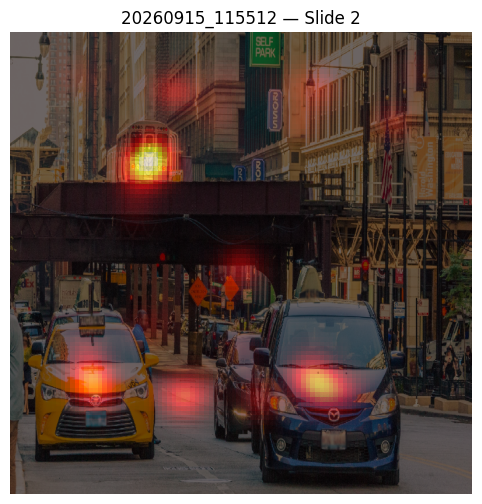

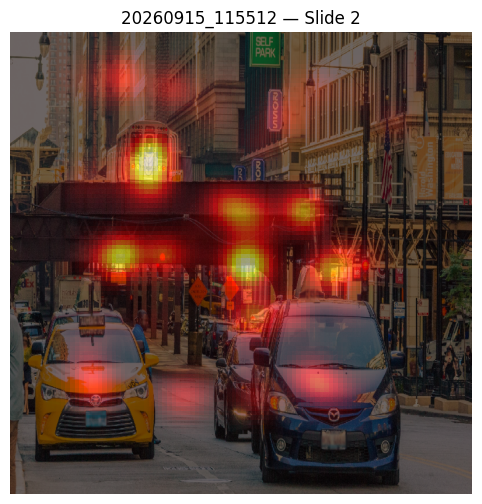

In [3]:
# Assuming you already have the data
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

analyzer = HeatmapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global heatmap statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# --- Plot heatmap for one image ---
example_slide = background_data.iloc[-1]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


▶ Global focus map statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,-31.962761,32.264814,4887


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260915_115512,-31.962761,32.264814,4887


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260915_115512,0,-14.596334,98.456481,1545
1,20260915_115512,1,-32.643512,8.548326,1811
2,20260915_115512,2,-48.682740,-6.478206,1531


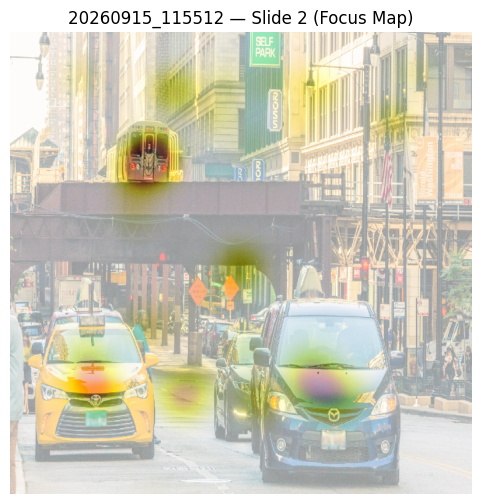

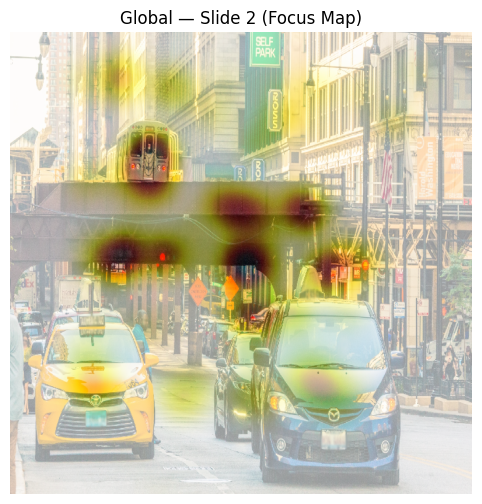

In [4]:
# --- Prepare background data ---
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

analyzer = FocusMapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global focus map statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# ============================================================
# 🖼 Plot focus map for one example slide
# ============================================================

example_slide = background_data.iloc[-1]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

# --- Focus map for single slide (individual subject) ---
analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']} (Focus Map)",
)

# --- Focus map using all gaze data for this slide (across subjects) ---
analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"Global — Slide {example_slide['slide_index']} (Focus Map)",
)

▶ Detecting saccades...


,set_name,slide_index,start_time,end_time,duration,x_start,y_start,x_end,y_end,amplitude,peak_velocity,mean_velocity,mean_acceleration
0,20260915_115512,0,13.195084,13.210837,0.031642,4.070263,-8.589292,9.186487,-10.474813,5.452609,365.925922,234.726366,157303.749634
1,20260915_115512,0,13.247796,13.262760,0.030384,11.150923,-13.546729,9.703217,-4.947960,8.719787,637.868975,378.100995,32553.472432
2,20260915_115512,0,13.297464,13.297464,0.018339,10.735474,-7.370353,9.372282,-7.399392,1.363501,74.350200,74.350200,4719.735967
3,20260915_115512,0,13.331694,13.482286,0.168986,19.852324,7.345605,15.279322,23.126847,16.430458,1319.866301,396.621039,14998.774300
4,20260915_115512,0,13.512477,13.548268,0.050765,6.741056,44.815207,6.355076,54.532278,9.724734,798.922758,370.351914,30755.062909


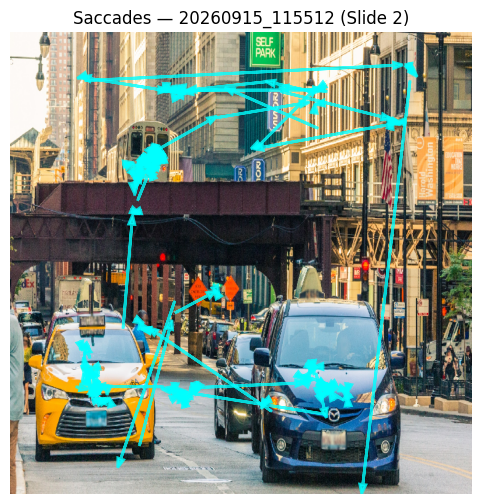

In [5]:
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

saccade_analyzer = SaccadeAnalyzer(
    output_folder=output_dir,
    method="ivt",               # "ivt" (velocity-based) or "acceleration"
    velocity_threshold=120.0,   # pixels/sec
    acceleration_threshold=6000.0,  # pixels/sec^2
    min_duration=0.015,         # seconds
)

print("▶ Detecting saccades...")
saccades = saccade_analyzer.analyze(background_data)
display(saccades.head())

example_slide = background_data.iloc[-1]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

saccade_analyzer.plot_analysis(
    saccades=saccades,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=example_slide["slide_index"],
    title=f"Saccades — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Detecting fixations...


,fix_start,fix_end,duration,x_mean,y_mean,dispersion,set_name,slide_index
0,13.195084,13.331694,0.136610,12.547779,-2.056173,61.485207,20260915_115512,0
1,13.347317,13.965041,0.617724,11.241089,46.795611,63.425807,20260915_115512,0
2,13.981873,14.163539,0.181666,10.133407,61.656091,88.120905,20260915_115512,0
3,14.178285,14.782436,0.604151,13.784068,92.240232,63.972552,20260915_115512,0
4,14.797685,15.559244,0.761559,3.712927,76.486244,70.016270,20260915_115512,0


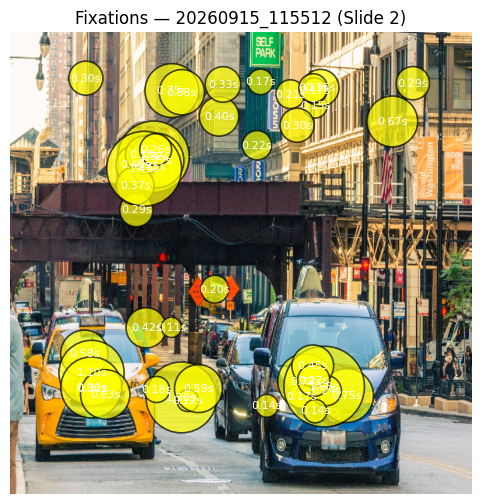

In [6]:
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

fixation_analyzer = FixationAnalyzer(
    output_folder=output_dir,
    method="dispersion",           # or "velocity"
    dispersion_threshold=60.0,     # pixels
    min_duration=0.08,             # seconds
)

print("▶ Detecting fixations...")
fixations = fixation_analyzer.analyze(background_data)
display(fixations.head())

example_slide = background_data.iloc[-1]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

fixation_analyzer.plot_analysis(
    fixations=fixations,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=example_slide["slide_index"],
    title=f"Fixations — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Performing gaze clustering...


,set_name,slide_index,screenshot_file,input_data,classification,user_classification,model_prediction,objects_bboxes,voice_file,voice_start_timestamp,...,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,avg_gaze_x,avg_gaze_y,avg_pupil_size,cluster
0,20260915_115512,2,output\20260915_115512\chickago-traffic.jpg,datasets/varia\cars\chickago-traffic.jpg,cars,cars,None,"{'image_bboxes': [{'class': 'grid', 'conf': 1....",output\20260915_115512\voice_002.wav,71.767,...,-28.754940,-183.462739,72.015839,-245.724034,3.525421,3.390854,21.630449,-214.593387,3.458138,0
1,20260915_115512,2,output\20260915_115512\chickago-traffic.jpg,datasets/varia\cars\chickago-traffic.jpg,cars,cars,None,"{'image_bboxes': [{'class': 'grid', 'conf': 1....",output\20260915_115512\voice_002.wav,71.767,...,-25.349979,-139.029551,33.171616,-155.021310,3.502243,3.375259,3.910818,-147.025430,3.438751,1
2,20260915_115512,2,output\20260915_115512\chickago-traffic.jpg,datasets/varia\cars\chickago-traffic.jpg,cars,cars,None,"{'image_bboxes': [{'class': 'grid', 'conf': 1....",output\20260915_115512\voice_002.wav,71.767,...,3.925323,-153.381371,25.810776,-171.785116,3.516373,3.370987,14.868050,-162.583244,3.443680,1
3,20260915_115512,2,output\20260915_115512\chickago-traffic.jpg,datasets/varia\cars\chickago-traffic.jpg,cars,cars,None,"{'image_bboxes': [{'class': 'grid', 'conf': 1....",output\20260915_115512\voice_002.wav,71.767,...,-10.008831,-131.137705,20.363960,-150.736284,3.512238,3.386642,5.177565,-140.936995,3.449440,1
4,20260915_115512,2,output\20260915_115512\chickago-traffic.jpg,datasets/varia\cars\chickago-traffic.jpg,cars,cars,None,"{'image_bboxes': [{'class': 'grid', 'conf': 1....",output\20260915_115512\voice_002.wav,71.767,...,-1.580029,-135.166454,21.521988,-148.479509,3.509995,3.378235,9.970980,-141.822982,3.444115,1


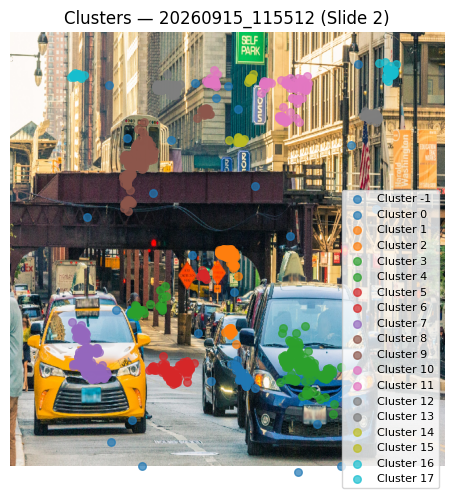

In [8]:
# ==============================================
# 👁️ Cluster Analyzer Demo
# ==============================================
from pathlib import Path
import pandas as pd

#background_data= loader.get_all_data(flatten=True)
background_data= loader.get_slide_data(loader.get_subjects()[-1],-1,flatten=True)
output_dir = Path("./analysis_outputs")

# Instantiate analyzer (DBSCAN by default)
cluster_analyzer = ClusterAnalyzer(
    output_folder=output_dir,
    eps=20,              # pixel distance for clustering
    min_samples=3,        # minimum points per cluster
)

print("▶ Performing gaze clustering...")
clustered_data = cluster_analyzer.analyze(background_data)
display(clustered_data.head())

# --- Visualization for one slide ---
example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

cluster_analyzer.plot_analysis(
    background_data=clustered_data,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=example_slide["slide_index"],
    title=f"Clusters — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Slide-level entropy


,entropy,convex_hull_area,num_points,set_name,slide_index
0,8.365636,182912.954844,1545,20260915_115512,0
1,8.584329,159272.037864,1811,20260915_115512,1
2,8.304350,345462.190729,1531,20260915_115512,2


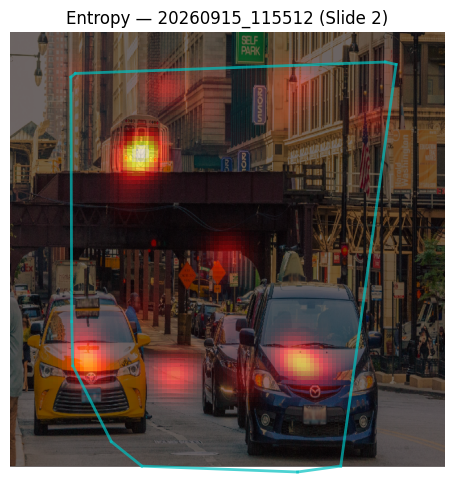

In [9]:
# ==============================================
# 🧠 Entropy Analyzer Demo
# ==============================================
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

entropy_analyzer = EntropyAnalyzer(output_folder=output_dir)

print("▶ Slide-level entropy")
entropy_results = entropy_analyzer.analyze(background_data, per="slide", bins=100, use_convex_hull=True)
display(entropy_results.head())

# --- Visualization for one example slide ---
example_slide = background_data.iloc[-1]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

entropy_analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"Entropy — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)
